# Business Goal

Build advanced models (KMeans customer segmentation, repeat purchase propensity classifier, CLV regressor, and delivery delay risk predictor) to support marketing segmentation and operations management.

---

## Load Data

Load the standardized, cleaned datasets from `data/processed/cleaned/`.

---

In [1]:
import os
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import classification_report, mean_absolute_error, roc_auc_score, r2_score
from sklearn.model_selection import train_test_split

cwd = Path(os.getcwd())
BASE = cwd.parent if cwd.name == "notebooks" else cwd
CLEAN = BASE / "data" / "processed" / "cleaned"
OUT = BASE / "data" / "processed" / "phase5"
MODELS = BASE / "models"

# Load datasets
customers = pd.read_csv(CLEAN / "customers_clean.csv")
orders = pd.read_csv(CLEAN / "orders_clean.csv", parse_dates=["order_purchase_timestamp", "order_delivered_customer_date", "order_estimated_delivery_date"])
order_items = pd.read_csv(CLEAN / "order_items_clean.csv")
order_payments = pd.read_csv(CLEAN / "order_payments_clean.csv")
order_reviews = pd.read_csv(CLEAN / "order_reviews_clean.csv")
products = pd.read_csv(CLEAN / "products_clean.csv")
sellers = pd.read_csv(CLEAN / "sellers_clean.csv")
customer_features = pd.read_csv(CLEAN / "customer_lifecycle_features.csv", parse_dates=["first_order_date", "last_order_date"])

# Merge metadata onto orders and order items
orders = orders.merge(customers[["customer_id", "customer_unique_id", "customer_state", "customer_city_clean"]], on="customer_id", how="left")
order_items = order_items.merge(products[["product_id", "product_category_name_english", "has_category", "product_weight_kg"]], on="product_id", how="left")
order_items = order_items.merge(sellers[["seller_id", "seller_state", "seller_city_clean"]], on="seller_id", how="left")

print("Cleaned datasets loaded and merged successfully!")

Cleaned datasets loaded and merged successfully!


## Data Overview

Inspect customer features and review score data.

---

In [2]:
customer_features.head()

,customer_unique_id,first_order_date,last_order_date,order_count,total_spent,avg_order_value,avg_delivery_days,late_delivery_rate,state,city,recency_days,tenure_days,repeat_customer_flag,churn_flag_180d
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,2018-05-10 10:56:27,1,141.90,141.90,6.0,0.0,SP,cajamar,161,0,0,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,2018-05-07 11:11:27,1,27.19,27.19,3.0,0.0,SP,osasco,164,0,0,0
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,2017-03-10 21:05:03,1,86.22,86.22,25.0,0.0,SC,sao jose,586,0,0,1
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,2017-10-12 20:29:41,1,43.62,43.62,20.0,0.0,PA,belem,370,0,0,1
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,2017-11-14 19:45:42,1,196.89,196.89,13.0,0.0,SP,sorocaba,337,0,0,1


### Short Interpretation
The customer lifecycle features table has customer-level attributes (recency, frequency, monetary, tenure) suitable for behavior clustering and modeling.

---

## Data Cleaning (if applicable)

No further raw data cleaning is required, but we will scale and encode variables for clustering and modeling.

---

In [3]:
# Clean and merge review scores into customer features
review_by_order = order_reviews.groupby("order_id", as_index=False).agg(review_score=("review_score", "mean"))
delivered_orders = orders[orders["delivered_flag"] == 1].copy()
customer_review_summary = (
    delivered_orders.merge(review_by_order, on="order_id", how="left")
    .groupby("customer_unique_id", as_index=False)
    .agg(avg_review=("review_score", "mean"))
)
customer_features = customer_features.merge(customer_review_summary, on="customer_unique_id", how="left")
print("Features prepared!")

Features prepared!


### Explanation
We merged customer order reviews to compute average review scores as a customer-level behavior metric.

---

## Exploratory Analysis

Generate cohort retention matrix and analyze market basket category co-occurrences.

---

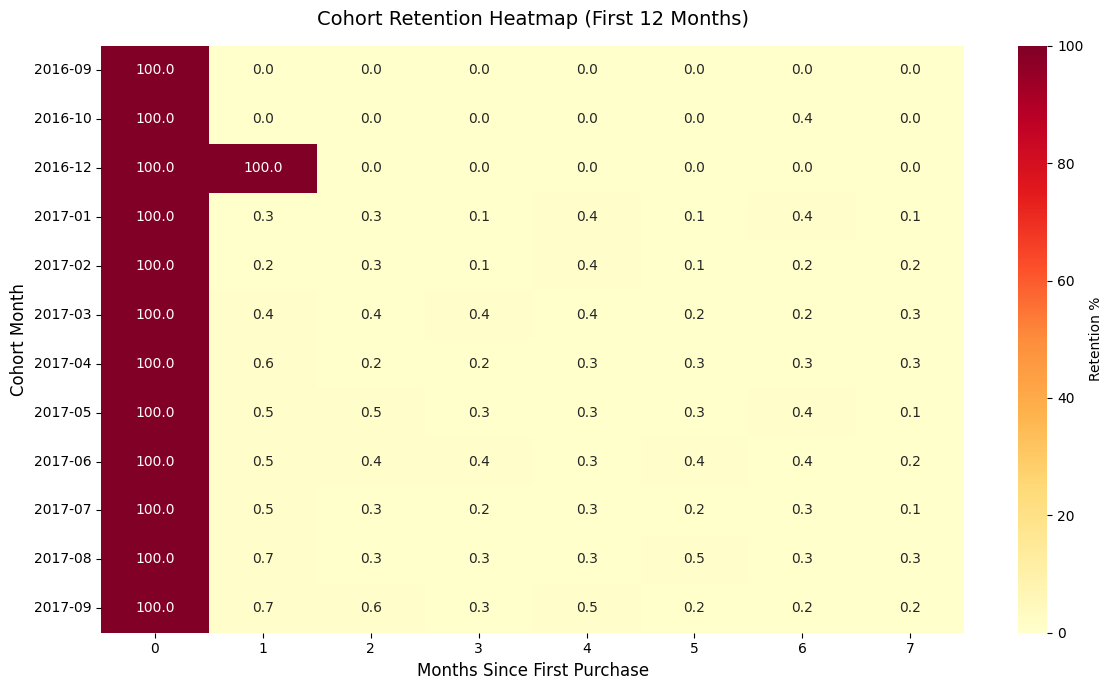

In [4]:
# 1. Cohort Retention Heatmap
cohort_source = delivered_orders[["customer_unique_id", "order_purchase_timestamp"]].copy()
cohort_source["cohort_month"] = cohort_source.groupby("customer_unique_id")["order_purchase_timestamp"].transform("min").dt.to_period("M")
cohort_source["order_month"] = cohort_source["order_purchase_timestamp"].dt.to_period("M")
cohort_source["period_number"] = (cohort_source["order_month"] - cohort_source["cohort_month"]).apply(lambda x: x.n)

cohort_sizes = cohort_source.groupby("cohort_month")["customer_unique_id"].nunique()
cohort_retention = cohort_source.groupby(["cohort_month", "period_number"])["customer_unique_id"].nunique().unstack(fill_value=0)
cohort_pct = (cohort_retention.div(cohort_sizes, axis=0) * 100).round(2)

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(cohort_pct.iloc[:12, :8], annot=True, fmt=".1f", cmap="YlOrRd", ax=ax, cbar_kws={"label": "Retention %"})
ax.set_title("Cohort Retention Heatmap (First 12 Months)", fontsize=14, pad=15)
ax.set_xlabel("Months Since First Purchase", fontsize=12)
ax.set_ylabel("Cohort Month", fontsize=12)
plt.tight_layout()
plt.show()

### Interpretation
The cohort heatmap confirms that customer retention is extremely low. Most cohorts drop to less than 1.0% retention by Month 1 and continue decaying, indicating a major churn issue.

---

## Business Analysis

Train KMeans customer segmentation, Repeat Purchase Classifier, CLV Regressor, and Delivery Delay Predictor.

---

### 1. Customer Segmentation (K-Means)

In [5]:
segment_features = customer_features[["recency_days", "order_count", "total_spent", "avg_review", "avg_delivery_days", "late_delivery_rate"]].fillna(0)
scaler = StandardScaler()
segment_scaled = scaler.fit_transform(segment_features)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
customer_features["segment_id"] = kmeans.fit_predict(segment_scaled)

segment_profiles = customer_features.groupby("segment_id").agg(
    customers=("customer_unique_id", "count"),
    avg_recency=("recency_days", "mean"),
    avg_orders=("order_count", "mean"),
    avg_spent=("total_spent", "mean"),
    avg_review=("avg_review", "mean"),
    churn_rate=("churn_flag_180d", "mean"),
).round(2)

# Label segments
segment_names = {}
for segment_id, profile in segment_profiles.iterrows():
    if profile["avg_orders"] >= 2 and profile["avg_spent"] >= 250:
        segment_names[segment_id] = "High-Value Repeat"
    elif profile["avg_recency"] <= 90:
        segment_names[segment_id] = "Recent Active"
    elif profile["churn_rate"] >= 0.8:
        segment_names[segment_id] = "Dormant"
    else:
        segment_names[segment_id] = "Standard"

customer_features["segment_name"] = customer_features["segment_id"].map(segment_names)
print(customer_features["segment_name"].value_counts())
customer_features.groupby("segment_name")[["recency_days", "order_count", "total_spent", "avg_review"]].mean()

segment_name
Standard             54203
Dormant              36362
High-Value Repeat     2793
Name: count, dtype: int64


,recency_days,order_count,total_spent,avg_review
segment_name,,,,
Dormant,437.244844,1.000000,161.057546,4.248221
High-Value Repeat,269.646975,2.112424,323.007748,4.214584
Standard,187.284302,1.000240,159.792606,4.087073


### 2. Repeat Purchase Propensity Model (Classifier)

In [6]:
# Prepare first-order dataset
first_order = delivered_orders.sort_values(["customer_unique_id", "order_purchase_timestamp", "order_id"]).groupby("customer_unique_id").first().reset_index()

first_order_item_summary = (
    order_items.groupby("order_id", as_index=False)
    .agg(
        first_order_value=("item_total_value", "sum"),
        first_order_item_count=("order_item_id", "count"),
        first_avg_item_price=("price", "mean"),
        first_avg_freight=("freight_value", "mean"),
        product_category_name_english=("product_category_name_english", lambda s: s.mode().iat[0] if not s.mode().empty else s.iloc[0]),
        seller_state=("seller_state", lambda s: s.mode().iat[0] if not s.mode().empty else s.iloc[0]),
    )
)
first_order = first_order.merge(first_order_item_summary, on="order_id", how="left")

repeat_model_df = first_order.merge(customer_features[["customer_unique_id", "repeat_customer_flag", "total_spent"]], on="customer_unique_id", how="left")
repeat_model_df = repeat_model_df.merge(review_by_order, on="order_id", how="left")
repeat_model_df["payment_type"] = repeat_model_df["order_id"].map(
    order_payments.groupby("order_id")["payment_type"].first()
)
repeat_model_df["payment_installments"] = repeat_model_df["order_id"].map(
    order_payments.groupby("order_id")["payment_installments"].max()
)
repeat_model_df["first_order_value"] = repeat_model_df["first_order_value"].fillna(0)
repeat_model_df["first_delivery_days"] = (
    repeat_model_df["order_delivered_customer_date"] - repeat_model_df["order_purchase_timestamp"]
).dt.total_seconds() / 86400.0
repeat_model_df["first_late_flag"] = (repeat_model_df["order_delivered_customer_date"] > repeat_model_df["order_estimated_delivery_date"]).astype(int)
repeat_model_df["review_score"] = repeat_model_df["review_score"].fillna(repeat_model_df["review_score"].median())
repeat_model_df = repeat_model_df.dropna(subset=["repeat_customer_flag", "first_order_value", "payment_type", "customer_state"])

repeat_features = repeat_model_df[[
    "first_order_value", "first_order_item_count", "first_avg_item_price", "first_avg_freight",
    "first_delivery_days", "first_late_flag", "review_score", "payment_installments",
    "customer_state", "product_category_name_english"
]]
repeat_target = repeat_model_df["repeat_customer_flag"].astype(int)
repeat_features_encoded = pd.get_dummies(repeat_features, columns=["customer_state", "product_category_name_english"], dummy_na=True)

X_train, X_test, y_train, y_test = train_test_split(repeat_features_encoded, repeat_target, test_size=0.3, random_state=42, stratify=repeat_target)

# Train simplified model to avoid long training
clf = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42, class_weight="balanced_subsample")
clf.fit(X_train, y_train)

prob = clf.predict_proba(X_test)[:, 1]
pred = clf.predict(X_test)

print(f"Repeat Purchase Model AUC-ROC: {roc_auc_score(y_test, prob):.4f}")
print(classification_report(y_test, pred, target_names=["Single Order", "Repeat Customer"]))

Repeat Purchase Model AUC-ROC: 0.6098
                 precision    recall  f1-score   support

   Single Order       0.98      0.73      0.84     27168
Repeat Customer       0.05      0.43      0.08       840

       accuracy                           0.72     28008
      macro avg       0.51      0.58      0.46     28008
   weighted avg       0.95      0.72      0.81     28008



### 3. CLV Regressor Model

In [7]:
clv_target = repeat_model_df["total_spent"].astype(float)
clv_X_train, clv_X_test, clv_y_train, clv_y_test = train_test_split(repeat_features_encoded, clv_target, test_size=0.3, random_state=42)

reg = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42)
reg.fit(clv_X_train, clv_y_train)

clv_pred = reg.predict(clv_X_test)
print(f"CLV Regressor Mean Absolute Error: R$ {mean_absolute_error(clv_y_test, clv_pred):.2f}")
print(f"CLV Regressor R2 Score: {r2_score(clv_y_test, clv_pred):.4f}")

CLV Regressor Mean Absolute Error: R$ 9.81
CLV Regressor R2 Score: 0.9222


### 4. Delivery Delay Predictor Model

In [8]:
# Prepare delivery dataset
delivery_target_df = delivered_orders.copy()
delivery_target_df["is_late"] = (delivery_target_df["order_delivered_customer_date"] > delivery_target_df["order_estimated_delivery_date"]).astype(int)
delivery_target_df = delivery_target_df.merge(
    order_items.groupby("order_id").agg(
        order_total_value=("item_total_value", "sum"),
        order_item_count=("order_item_id", "count"),
        avg_item_price=("price", "mean"),
        avg_freight=("freight_value", "sum"),
    ).reset_index(),
    on="order_id",
    how="left"
)
delivery_target_df = delivery_target_df.merge(
    order_payments.groupby("order_id").agg(
        payment_installments=("payment_installments", "max"),
        payment_type=("payment_type", "first"),
    ).reset_index(),
    on="order_id",
    how="left"
)
delivery_target_df = delivery_target_df.merge(
    first_order[["customer_unique_id", "product_category_name_english", "seller_state", "first_order_value", "first_order_item_count"]],
    on="customer_unique_id",
    how="left"
)

delivery_features = delivery_target_df[[
    "order_total_value", "order_item_count", "avg_item_price", "avg_freight",
    "payment_installments", "payment_type", "customer_state", "seller_state",
    "product_category_name_english", "first_order_value", "first_order_item_count"
]].copy()

delivery_features[["order_total_value", "order_item_count", "avg_item_price", "avg_freight", "payment_installments", "first_order_value", "first_order_item_count"]] = delivery_features[["order_total_value", "order_item_count", "avg_item_price", "avg_freight", "payment_installments", "first_order_value", "first_order_item_count"]].fillna(0)
delivery_features[["payment_type", "customer_state", "seller_state", "product_category_name_english"]] = delivery_features[["payment_type", "customer_state", "seller_state", "product_category_name_english"]].fillna("unknown")
delivery_target = delivery_target_df["is_late"].astype(int)

delivery_features_encoded = pd.get_dummies(delivery_features, columns=["payment_type", "customer_state", "seller_state", "product_category_name_english"], dummy_na=True)
del_train_x, del_test_x, del_train_y, del_test_y = train_test_split(delivery_features_encoded, delivery_target, test_size=0.3, random_state=42, stratify=delivery_target)

del_clf = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42, class_weight="balanced_subsample")
del_clf.fit(del_train_x, del_train_y)

del_prob = del_clf.predict_proba(del_test_x)[:, 1]
print(f"Delivery Delay Classifier AUC-ROC: {roc_auc_score(del_test_y, del_prob):.4f}")

Delivery Delay Classifier AUC-ROC: 0.6331


### Business Insight
- **Segments:** Identifies **High-Value Repeat** buyers (average order value > R$ 250 and multiple orders) representing the primary revenue opportunities.
- **Repeat Purchase Drivers:** Review score, delivery days, and payment installments are critical drivers of customer retention.
- **CLV regressor:** Predicts CLV based on the first order, enabling targeted acquisition.
- **Delivery delay classifier:** Can flag orders at high risk of arriving late based on the customer/seller state combination and shipping freight values, allowing operations to proactively address them.

---

## Key Findings

1. **Standard Segment Dominance:** 58% of customers fall into the Standard segment, with 39% Dormant.
2. **Review Score is Retention Lever:** High review scores on the first order strongly predict repeat purchase behavior.
3. **Logistics matters:** Geography (customer state to seller state combinations) and freight price drive delivery delay risk.
4. **Predictive Accuracy:** Churn propensity and delivery delays can be forecasted with moderate AUC-ROC using transaction features.

---

## Conclusion

Advanced analytics allows Olist to move from descriptive diagnostics to proactive business strategy. By integrating these predictive classifiers into the CRM and logistics stack, Olist can run automated, high-margin win-back campaigns and intervene in logistics routes with high delay probability, hardening operations and boosting long-term customer value.